# Threshold Selection Analysis



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from itertools import cycle

## Config

In [3]:
# ── ────────────────────────────────────────────────────────────────────
# CSV columns: m, n, t, model, gtruth, retrieved, precision, recall,
#              tp, fp, fn, tn, repetition, qid, query
DATA_PATH    = "../data/processed/threshold_selection_movie.csv"
DATASET_NAME = "movie"   # appears in plot titles

# ────────────────────────────────────────────────────────────────────
# Options: 'f1'  |  'precision'  |  'recall'
METRIC = 'f1'

# ───────────────────────────────────────────────────────────
SHOW_TAU_LINE = True    # show the sqrt(n/m) reference line
TAU_LABEL     = False    # annotate the tau line with its value
SHOW_GRID     = True
AXIS_MARGIN   = 0.02    # padding around [0, 1] on both axes
FIG_SIZE      = (14, 10)  # overall grid figure size
ZOOM_FIG_SIZE = (7, 5)    # figure size for the zoomed single-cell plot

# ────────────────────────────────────────────────────
# Models in the same family share a hue; variants differ in lightness & linestyle.
# Members listed explicitly — no magic prefix matching needed.
METHOD_FAMILIES = {
    'HRR': [
        'HRR_300', 'HRR_512', 'HRR_1024', 'HRR_2048',
    ],
    'BSC': [
        'BSC_300', 'BSC_512', 'BSC_1024', 'BSC_2048', 'BSC_4096', 'BSC_8192',
    ],
    'SemHDC': [
        'SemHDC_FastText_300',
    ],
    'EmbDI': [
        'EmbDI',
    ],
}

# Base hues per family (degrees, 0–360).  Add a key here if you add a new family.
FAMILY_HUES = {
    'HRR':    210,   # blues
    'BSC':    30,    # oranges
    'SemHDC': 140,   # greens
    'EmbDI':  290,   # purples
    '_other': 0,     # gray fallback
}

## Load & prepare data

In [4]:
# CSV columns: m, n, t, model, gtruth, retrieved, precision, recall,
#              tp, fp, fn, tn, repetition, qid, query
df = pd.read_csv(DATA_PATH)

# Cast numeric columns
for col in ['t', 'recall', 'precision', 'tp', 'fp', 'fn']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Compute F1 from precision/recall (falls back to tp/fp/fn if needed)
if 'f1' not in df.columns:
    denom = df['recall'] + df['precision']
    df['f1'] = np.where(
        denom > 0,
        2 * df['recall'] * df['precision'] / denom,
        0.0
    )

# Aggregate over repetitions / queries
agg_df = (
    df.groupby(['model', 'n', 'm', 't'], as_index=False)
      .agg(recall=('recall', 'mean'),
           precision=('precision', 'mean'),
           f1=('f1', 'mean'))
)

q_lengths  = np.sort(agg_df['n'].unique())   # grid rows  (query length)
c_nums     = np.sort(agg_df['m'].unique())   # grid cols  (# columns)
all_models = sorted(agg_df['model'].unique())

print(f"Rows (n) : {list(q_lengths)}")
print(f"Cols (m) : {list(c_nums)}")
print(f"Models   : {all_models}")
print(f"Metric   : {METRIC}")

Rows (n) : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Cols (m) : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Models   : ['BSC_1024', 'BSC_2048', 'BSC_300', 'BSC_4096', 'BSC_512', 'BSC_8192', 'EmbDI', 'HRR_1024', 'HRR_2048', 'HRR_300', 'HRR_512', 'SemHDC_FastText_300']
Metric   : f1


## Build color palette

In [5]:
import colorsys

def hsl_to_rgb(h, s, l):
    """h in [0, 360], s and l in [0, 1]."""
    return colorsys.hls_to_rgb(h / 360, l, s)

def make_family_colors(models, family_map, hue_map):
    """Return (palette, linestyles, assigned) dicts keyed by model name.

    Assignment priority:
      1. Explicit member list in family_map.
      2. Prefix match (family name is a prefix of the model name, case-insensitive).
      3. '_other' → gray.
    """
    from collections import defaultdict

    # Build reverse lookup: member → family
    explicit = {}
    for fam, members in family_map.items():
        for m in members:
            explicit[m] = fam

    assigned = {}
    for model in models:
        if model in explicit:
            assigned[model] = explicit[model]
        else:
            # prefix fallback
            matched = False
            for fam in family_map:
                if model.upper().startswith(fam.upper()):
                    assigned[model] = fam
                    matched = True
                    break
            if not matched:
                assigned[model] = '_other'

    family_members = defaultdict(list)
    for model, fam in assigned.items():
        family_members[fam].append(model)

    palette    = {}
    linestyles = {}
    # Linestyles ordered from most to least prominent
    ls_cycle = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]

    for fam, members in family_members.items():
        hue = hue_map.get(fam, 0)
        n   = len(members)
        # Spread lightness: darkest for lowest dimension (sorted ascending)
        lightnesses = np.linspace(0.28, 0.62, max(n, 1))
        for k, model in enumerate(sorted(members)):
            if fam == '_other':
                g = np.linspace(0.40, 0.70, max(n, 1))[k]
                palette[model] = (g, g, g)
            else:
                palette[model] = hsl_to_rgb(hue, 0.75, lightnesses[k])
            linestyles[model] = ls_cycle[k % len(ls_cycle)]

    return palette, linestyles, assigned

COLOR_MAP, LS_MAP, FAMILY_ASSIGNED = make_family_colors(
    all_models, METHOD_FAMILIES, FAMILY_HUES
)

print("Color assignments (family → models):")
from collections import defaultdict
_by_fam = defaultdict(list)
for mdl, fam in FAMILY_ASSIGNED.items():
    _by_fam[fam].append(mdl)
for fam, mdls in sorted(_by_fam.items()):
    print(f"  {fam:10s}: {', '.join(sorted(mdls))}")

Color assignments (family → models):
  BSC       : BSC_1024, BSC_2048, BSC_300, BSC_4096, BSC_512, BSC_8192
  EmbDI     : EmbDI
  HRR       : HRR_1024, HRR_2048, HRR_300, HRR_512
  SemHDC    : SemHDC_FastText_300


## Shared plotting helper

In [6]:
METRIC_LABEL = {'f1': 'F1 Score', 'precision': 'Precision', 'recall': 'Recall'}
LIMITS = (0 - AXIS_MARGIN, 1 + AXIS_MARGIN)

def plot_one(ax, fdf, metric, show_tau=True, show_legend=False):
    """Draw one subplot on *ax* using the pre-built global palette."""
    for model, grp in fdf.groupby('model'):
        color = COLOR_MAP.get(model, (0.5, 0.5, 0.5))
        ls    = LS_MAP.get(model, '-')
        ax.plot(grp['t'], grp[metric],
                label=model, color=color,
                linestyle=ls, linewidth=1.8)

    if show_tau and len(fdf) > 0:
        n_val = fdf['n'].iloc[0]
        m_val = fdf['m'].iloc[0]
        tau = (n_val / m_val) ** 0.5
        ax.axvline(x=tau, color='crimson', linestyle=':', linewidth=1.2,
                   label=f'τ={tau:.2f}')
        if TAU_LABEL:
            ax.text(tau + 0.01, LIMITS[1] - 0.08, f'τ={tau:.2f}',
                    color='crimson', fontsize=7, va='top')

    ax.set_xlim(*LIMITS)
    ax.set_ylim(*LIMITS)
    if SHOW_GRID:
        ax.grid(True, linestyle='--', alpha=0.4)

    if show_legend:
        ax.legend(fontsize=8, loc='lower right', framealpha=0.8)


def make_legend_handles():
    """Global legend: one entry per model, grouped by family, with family headers."""
    from collections import defaultdict
    by_family = defaultdict(list)
    for model in all_models:
        by_family[FAMILY_ASSIGNED.get(model, '_other')].append(model)

    handles = []
    # Respect the order defined in METHOD_FAMILIES, then '_other'
    ordered_fams = list(METHOD_FAMILIES.keys()) + ['_other']
    for fam in ordered_fams:
        members = sorted(by_family.get(fam, []))
        if not members:
            continue
        # Family header (invisible line, bold label)
        handles.append(Line2D([0], [0], color='none',
                               label=f'── {fam} ──'))
        for model in members:
            handles.append(Line2D([0], [0],
                                  color=COLOR_MAP[model],
                                  linestyle=LS_MAP[model],
                                  linewidth=2.2,
                                  label=f'  {model}'))
    # τ reference line
    handles.append(Line2D([0], [0], color='crimson', linestyle=':', linewidth=1.5,
                           label='τ = √(n/m)'))
    return handles

## Full grid plot

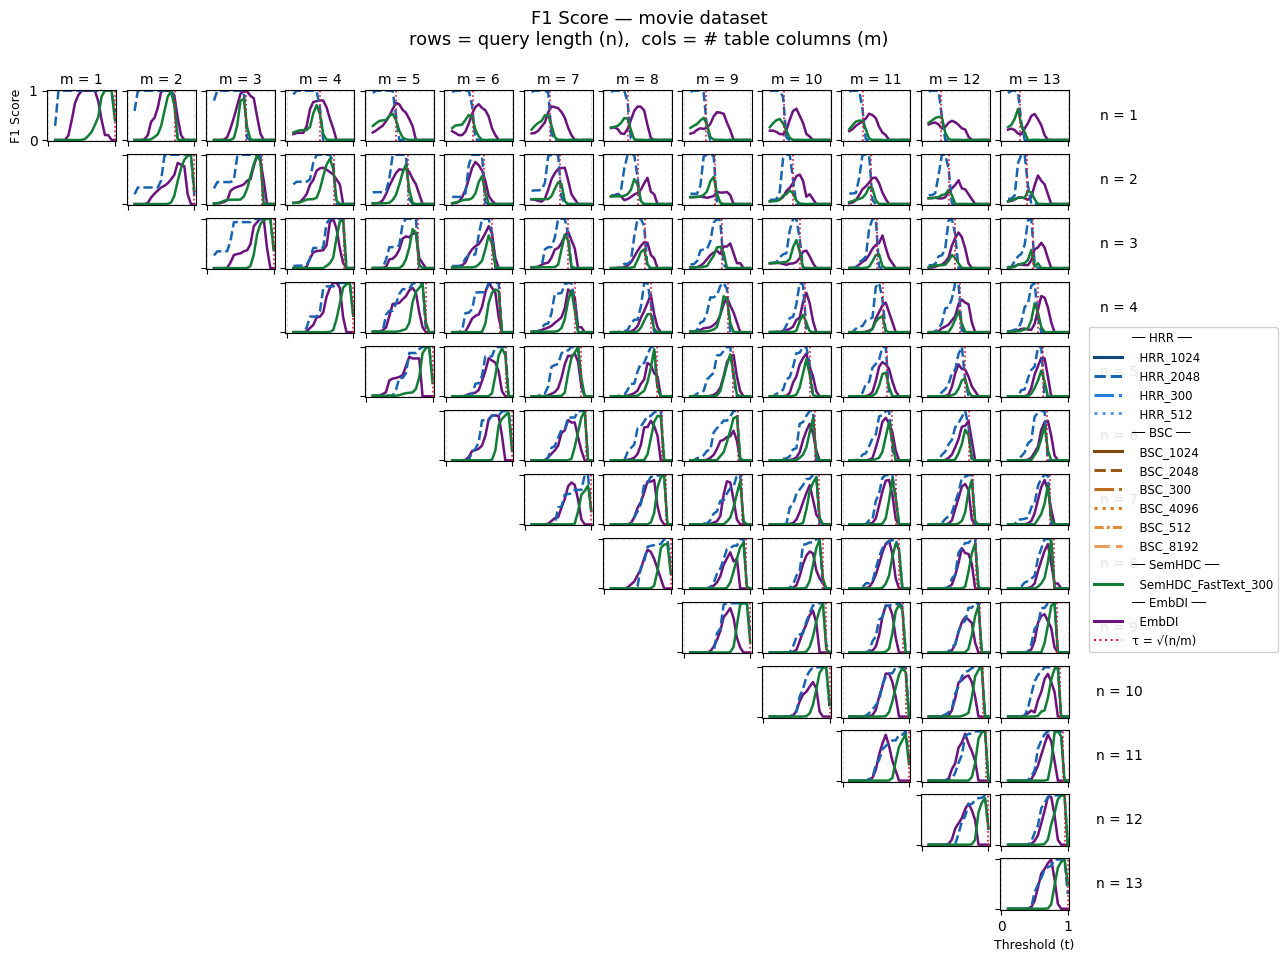

In [7]:
MODELS_IN = [
    "EmbDI",
    # "BSC_300", "BSC_512", "BSC_1024", "BSC_2048", "BSC_4096", "BSC_8192",
    # "HRR_300", "HRR_512", "HRR_1024", 
    "HRR_2048",
    "SemHDC_FastText_300",
]

nrows, ncols = len(q_lengths), len(c_nums)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=FIG_SIZE,
    sharex=True, sharey=True,
    constrained_layout=False
)
plt.subplots_adjust(left=0.07, right=0.80, top=0.90, bottom=0.08,
                    hspace=0.25, wspace=0.15)

# Ensure axes is always 2-D
if nrows == 1: axes = axes[np.newaxis, :]
if ncols == 1: axes = axes[:, np.newaxis]

for i, q_len in enumerate(q_lengths):
    for j, c_num in enumerate(c_nums):
        ax = axes[i, j]
        if j < i:                       # hide lower-triangle (optional)
            ax.set_visible(False)
            continue
        fdf = agg_df[(agg_df['n'] == q_len) & (agg_df['m'] == c_num) & (agg_df['model'].isin(MODELS_IN))]
        plot_one(ax, fdf, METRIC, show_tau=SHOW_TAU_LINE)

# Column headers (top) = m values
for j, c_num in enumerate(c_nums):
    axes[0, j].set_title(f'm = {int(c_num)}', fontsize=10, pad=4)

# Row labels (right side of grid) = n values
for i, q_len in enumerate(q_lengths):
    axes[i, -1].yaxis.set_label_position('right')
    axes[i, -1].set_ylabel(f'n = {int(q_len)}', rotation=0,
                            labelpad=36, fontsize=10, va='center')

# Axis labels on border cells
for ax in axes[-1, :]:
    ax.set_xlabel('Threshold (t)', fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel(METRIC_LABEL[METRIC], fontsize=9)

# Legend in the right margin (stays readable with many models)
fig.legend(handles=make_legend_handles(),
           loc='center left',
           bbox_to_anchor=(0.81, 0.50),
           fontsize=8.5, framealpha=0.9,
           handlelength=2.4)

fig.suptitle(
    f"{METRIC_LABEL[METRIC]} — {DATASET_NAME} dataset\n"
    f"rows = query length (n),  cols = # table columns (m)",
    fontsize=13
)

plt.show()

## specific (n, m) cell in detail

Change `ZOOM_N` and `ZOOM_M` to any values from the grid, then run the cell.

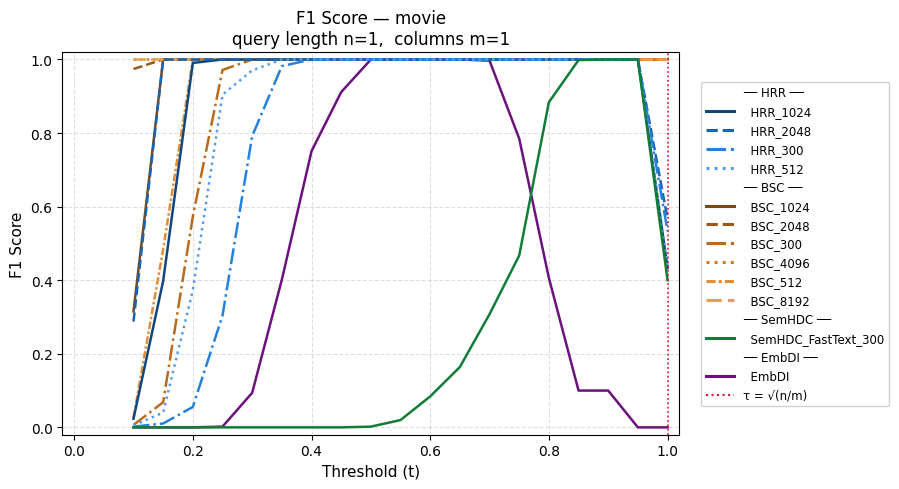

In [8]:
# ─────────────────────────────────────────────────────────────
ZOOM_N = q_lengths[0]      # query length  
ZOOM_M = c_nums[0]         # # columns    
# ─────────────────────────────────────────────────────────────────────────────

MODELS_IN = [
    "EmbDI",
    "BSC_300", "BSC_512", "BSC_1024", "BSC_2048", "BSC_4096", "BSC_8192",
    "HRR_300", "HRR_512", "HRR_1024", "HRR_2048",
    "SemHDC_FastText_300",
]

fdf = agg_df[(agg_df['n'] == ZOOM_N) & (agg_df['m'] == ZOOM_M) & (agg_df['model'].isin(MODELS_IN))]

if fdf.empty:
    print(f"No data for n={ZOOM_N}, m={ZOOM_M}. "
          f"Available n: {list(q_lengths)}, m: {list(c_nums)}")
else:
    fig, ax = plt.subplots(figsize=ZOOM_FIG_SIZE)
    plot_one(ax, fdf, METRIC, show_tau=SHOW_TAU_LINE, show_legend=False)

    fig.legend(handles=make_legend_handles(),
               loc='center left', bbox_to_anchor=(1, 0.50),
               fontsize=8.5, framealpha=0.9, handlelength=2.4)

    ax.set_xlabel('Threshold (t)', fontsize=11)
    ax.set_ylabel(METRIC_LABEL[METRIC], fontsize=11)
    ax.set_title(
        f"{METRIC_LABEL[METRIC]} — {DATASET_NAME}\n"
        f"query length n={ZOOM_N},  columns m={ZOOM_M}",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()


## Compare all three metrics side-by-side for one (n, m) cell

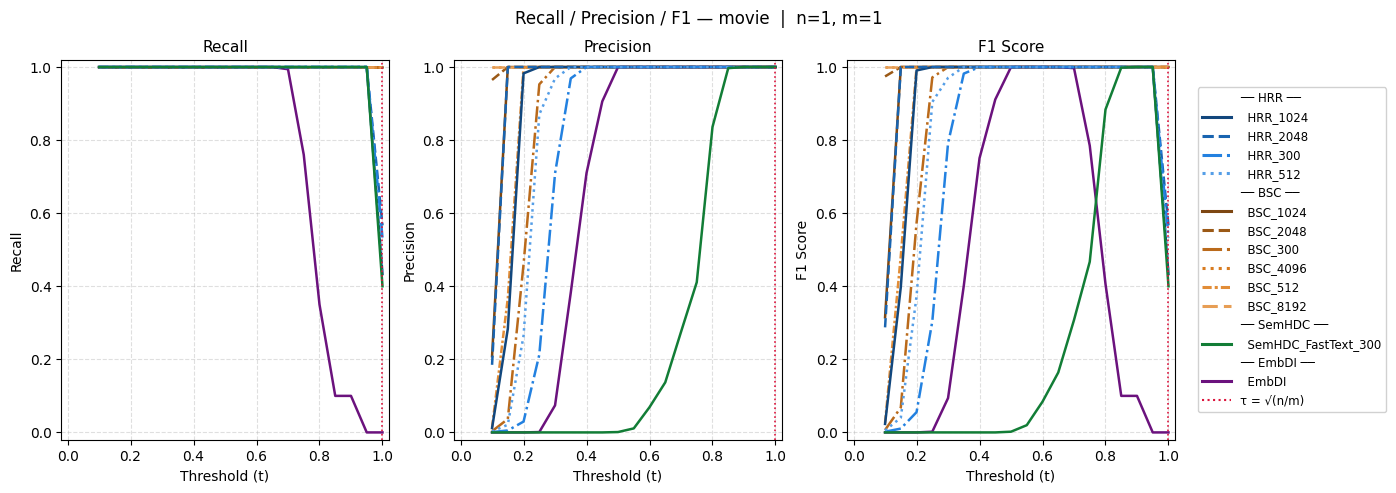

In [9]:
# Uses the same ZOOM_N / ZOOM_M set above
fdf = agg_df[(agg_df['n'] == ZOOM_N) & (agg_df['m'] == ZOOM_M)]

if not fdf.empty:
    fig, axes3 = plt.subplots(1, 3, figsize=(17, 5), sharey=False, sharex=True)
    for ax, metric in zip(axes3, ['recall', 'precision', 'f1']):
        plot_one(ax, fdf, metric, show_tau=SHOW_TAU_LINE)
        ax.set_title(METRIC_LABEL[metric], fontsize=11)
        ax.set_xlabel('Threshold (t)', fontsize=10)
        ax.set_ylabel(METRIC_LABEL[metric], fontsize=10)

    plt.subplots_adjust(right=0.78, bottom=0.12)
    fig.legend(handles=make_legend_handles(),
               loc='center left', bbox_to_anchor=(0.79, 0.50),
               fontsize=8.5, framealpha=0.9, handlelength=2.4)
    fig.suptitle(
        f"Recall / Precision / F1 — {DATASET_NAME}  |  n={ZOOM_N}, m={ZOOM_M}",
        fontsize=12
    )
    plt.show()

## Compare precision, recall, and F1 for one model in one graph

Change `ZOOM_N`, `ZOOM_M`, and `ZOOM_MODEL` to any values from the grid, then run the cell.

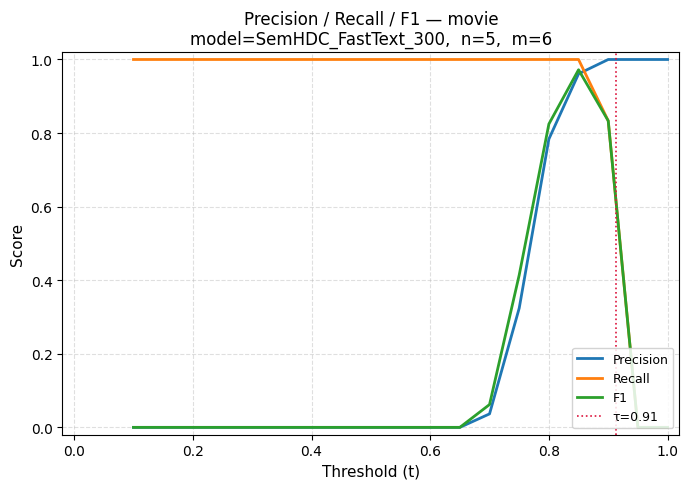

In [10]:
# ───────────────────────────────────────────────────
ZOOM_N = 5      # query length  
ZOOM_M = 6         # # columns    
ZOOM_MODEL = "EmbDI"      # change to any model present in agg_df
ZOOM_MODEL = 'SemHDC_FastText_300'
# SHOW_TAU_LINE = False
# ─────────────────────────────────────────────────────────────────────────────

fdf = agg_df[
    (agg_df['n'] == ZOOM_N) &
    (agg_df['m'] == ZOOM_M) &
    (agg_df['model'] == ZOOM_MODEL)
]

if fdf.empty:
    print(f"No data for n={ZOOM_N}, m={ZOOM_M}, model={ZOOM_MODEL}. "
          f"Available models: {list(all_models)}")
else:
    plot_df = fdf.sort_values('t')

    fig, ax = plt.subplots(figsize=ZOOM_FIG_SIZE)
    ax.plot(plot_df['t'], plot_df['precision'], label='Precision', linewidth=2.0, color='#1f77b4')
    ax.plot(plot_df['t'], plot_df['recall'], label='Recall', linewidth=2.0, color='#ff7f0e')
    ax.plot(plot_df['t'], plot_df['f1'], label='F1', linewidth=2.0, color='#2ca02c')

    if SHOW_TAU_LINE and len(plot_df) > 0:
        tau = (ZOOM_N / ZOOM_M) ** 0.5
        ax.axvline(x=tau, color='crimson', linestyle=':', linewidth=1.2, label=f'τ={tau:.2f}')
        if TAU_LABEL:
            ax.text(tau + 0.01, LIMITS[1] - 0.08, f'τ={tau:.2f}',
                    color='crimson', fontsize=7, va='top')

    ax.set_xlim(*LIMITS)
    ax.set_ylim(*LIMITS)
    if SHOW_GRID:
        ax.grid(True, linestyle='--', alpha=0.4)

    ax.set_xlabel('Threshold (t)', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(
        f"Precision / Recall / F1 — {DATASET_NAME}\n"
        f"model={ZOOM_MODEL},  n={ZOOM_N},  m={ZOOM_M}",
        fontsize=12
    )
    ax.legend(fontsize=9, loc='lower right', framealpha=0.85)

    plt.tight_layout()
    plt.show()